In [70]:
import tensorflow  as tf
from tensorflow.keras.datasets import cifar10

In [71]:
(xtr, ytr), (xte, yte)  = cifar10.load_data()

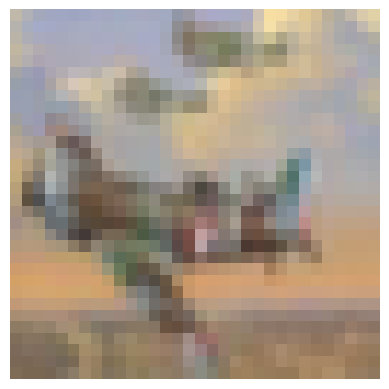

In [72]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.where((ytr.flatten() == 0) | (ytr.flatten() == 2))[0]

x_label = xtr[idx]   # images
y_label = ytr[idx]   # labels

plt.imshow(x_label[-9])
plt.axis("off")
plt.show()

In [73]:
import numpy as np

labels, counts = np.unique(y_label, return_counts=True)
dict(zip(labels.flatten(), counts))

{np.uint8(0): np.int64(5000), np.uint8(2): np.int64(5000)}

Now time for model

# CNN

In [74]:
from tensorflow.keras.models import Sequential as sq
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [75]:
cnn_model = sq([
    tf.keras.layers.Input(shape=(32,32,3)), # 3072 flatten me
    tf.keras.layers.Rescaling(1./225),
    Conv2D(32,(2,2), activation="relu"),
    Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.Dropout(0.2),
    # here poiling come BUT 😒😒
    Flatten(),
    Dense(64, activation= "relu"),
    tf.keras.layers.Dropout(0.5),
    Dense(32, activation= "relu"),
    Dense(2, activation= "softmax")
])

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [76]:
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 31, 31, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     3,444,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,465,858 (13.22 MB)

 Trainable params: 3,465,858 (13.22 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
y_bin = tf.cast(y_label == 2, tf.int32)

In [78]:
cnn_model.fit(x_label, y_bin, epochs=10, validation_split=0.2, batch_size=64) # batch_size=32 by defalt

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6907 - loss: 0.6489 - val_accuracy: 0.8325 - val_loss: 0.3996
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8273 - loss: 0.4084 - val_accuracy: 0.8555 - val_loss: 0.3418
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8560 - loss: 0.3440 - val_accuracy: 0.8665 - val_loss: 0.3303
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8663 - loss: 0.3172 - val_accuracy: 0.8790 - val_loss: 0.2974
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8848 - loss: 0.2854 - val_accuracy: 0.8740 - val_loss: 0.3146
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8844 - loss: 0.2683 - val_accuracy: 0.8855 - val_loss: 0.2885
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9115 - loss: 0.2273 - val_accuracy: 0.8955 - val_loss: 0.2713
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9065 - loss: 0.2205 - val_accuracy: 0

In [79]:
# (xte, yte)
# idx = np.where((ytr.flatten() == 0) | (ytr.flatten() == 2))[0]
# x_label = xtr[idx]   # images
# y_label = ytr[idx]   # labels
idx = np.where((yte.flatten() == 0) | (yte.flatten() == 2))[0]
x_label = xte[idx]   # images
y_label = yte[idx]   # labels
y_bin = tf.cast(y_label == 2, tf.int32)

cnn_model.evaluate(x_label, y_bin)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8669 - loss: 0.3378


[0.3120010197162628, 0.8799999952316284]

In [80]:
y_pred_prob = cnn_model.predict(x_label)
y_pred_class = tf.argmax(y_pred_prob, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [85]:
y_bin = tf.cast(y_bin, tf.int64)   # int64 match for argmax

acc = tf.reduce_mean(tf.cast(y_pred_class == y_bin, tf.float32))
print("Test Accuracy:", acc.numpy())

Test Accuracy: 0.5




---
# ANN with my style


In [86]:
(xtr, ytr), (xte, yte)  = cifar10.load_data()
idx = np.where((ytr.flatten() == 0) | (ytr.flatten() == 2))[0]
x_label = xtr[idx].reshape(len(idx), -1)   # images
y_label = ytr[idx]
y_bin = tf.cast(y_label == 2, tf.int32) # labels



In [93]:
print(x_label.shape)  # (N, 3072)
print(y_bin.shape)
np.unique(y_bin)

(10000, 3072)
(10000, 1)


array([0, 1], dtype=int32)

In [92]:
np.unique(y_bin)

array([0, 1], dtype=int32)

In [94]:
ann_model = sq([
    tf.keras.layers.Input(shape=(3072,)),
    Dense(2000, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    Dense(1000, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    Dense(500, activation="relu"),
    Dense(2,activation="softmax")
])
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
ann_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 2000)           │     6,146,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1000)           │     2,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │         1,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,648,502 (32.99 MB)

 Trainable params: 8,648,502 (32.99 MB)

 Non-trainable params: 0 (0.00 B)

In [97]:
ann_model.fit(x_label,y_bin, epochs=20, validation_split=0.2, batch_size=64)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5626 - loss: 0.6940 - val_accuracy: 0.5185 - val_loss: 0.6938
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5006 - loss: 0.6923 - val_accuracy: 0.4885 - val_loss: 0.6913
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5258 - loss: 0.6885 - val_accuracy: 0.5185 - val_loss: 0.6919
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4960 - loss: 0.7002 - val_accuracy: 0.4875 - val_loss: 0.6912
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4980 - loss: 0.6970 - val_accuracy: 0.4840 - val_loss: 0.6939
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5145 - loss: 0.6987 - val_accuracy: 0.4865 - val_loss: 0.6918
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5099 - loss: 0.6920 - val_accuracy: 0.4865 - val_loss: 0.6921
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5079 - loss: 0.6897 - val_accuracy: 0

In [98]:
idx = np.where((yte.flatten() == 0) | (yte.flatten() == 2))[0]
x_label = xte[idx].reshape(len(idx), -1)   # images
y_label = yte[idx]   # labels
y_bin = tf.cast(y_label == 2, tf.int32)



In [99]:
ann_model.evaluate(x_label,y_bin)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5008 - loss: 0.6914


[0.6921899318695068, 0.5019999742507935]

In [100]:
y_pred = ann_model.predict(x_label)
y_pred_class = tf.argmax(y_pred, axis=1)
y_bin = tf.cast(y_bin, tf.int64)
acc = tf.reduce_mean(tf.cast(y_pred_class == y_bin, tf.float32))
print("Test Accuracy:", acc.numpy())

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.5
